In [8]:
import pennylane as qml
from pennylane import qchem
import matplotlib.pyplot as plt
from pennylane import numpy as np
import scipy

In [2]:
part = qml.data.load(
    "qchem",
    molname="H2",
    basis="STO-3G",
    bondlength=0.74,
    attributes=["hamiltonian", "hf_state", "fci_energy"])[0]

H = part.hamiltonian
hf = part.hf_state
fci_energy = part.fci_energy
n_qubits = len(hf)

In [3]:
dev = qml.device('default.qubit', wires = n_qubits)

def rot_layer(params, wires):
    for i, w in enumerate(wires):
        qml.RY(params[2*i], wires=w)
        qml.RZ(params[2*i+1], wires=w)
    for j in range(len(wires)-1):
        qml.CNOT(wires=[wires[j], wires[j+1]])

In [10]:
@qml.qnode(dev)
def hardware_ansatz(params, n_layers):
    for layer in range(n_layers):
        start = 2*layer*n_qubits
        rot_layer(params[start:start+2*n_qubits], range(n_qubits))
    return qml.expval(H)
    
@qml.qnode(dev)
def uccsd_ansatz(params):
    qml.BasisState(hf, wires=range(n_qubits))
    qml.DoubleExcitation(params[0], wires=range(n_qubits))
    return qml.expval(H)
    
@qml.qnode(dev)
def extended_ansatz(params):
    qml.BasisState(hf, wires=range(n_qubits))
    qml.SingleExcitation(params[0], wires=[0, 2])
    qml.SingleExcitation(params[1], wires=[1, 3])
    qml.DoubleExcitation(params[2], wires=range(n_qubits))
    return qml.expval(H)

In [11]:
def run_vqe(cost_function, n_params, n_steps=100):
    opt = qml.GradientDescentOptimizer(stepsize=0.4)
    params = np.array(np.random.randn(n_params)*0.1, requires_grad = True)

    energies = []
    for _ in range(n_steps):
        params, energy = opt.step_and_cost(cost_function, params)
        energies.append(energy)
    return energies[-1], energies

In [13]:
e_hw , hist_hw = run_vqe(lambda p : hardware_ansatz(p , n_layers =2),n_params =2* n_qubits *2)
e_uccsd , hist_uccsd = run_vqe(uccsd_ansatz, n_params =1)
e_ext , hist_ext = run_vqe(extended_ansatz, n_params =3)

print(f" Hardware - efficient : { e_hw} Ha ")
print(f" UCCSD : { e_uccsd} Ha ")
print(f" Extended : { e_ext} Ha ")
print(f" Exact ( FCI ) : -1.1373 Ha ") 

 Hardware - efficient : -0.5309518052062562 Ha 
 UCCSD : -1.1372838216460397 Ha 
 Extended : -1.1372838216460388 Ha 
 Exact ( FCI ) : -1.1373 Ha 


In [16]:
def measure_gradient_variance(n_qubits, n_layers, n_samples=200):

    dev = qml.device('default.qubit', wires=n_qubits)
    n_params = 2 * n_qubits * n_layers

    @qml.qnode(dev)
    def barren_circ(params):
        for layer in range(n_layers):
            start = 2 * layer * n_qubits
            rot_layer(params[start:start + 2 * n_qubits], range(n_qubits))
        return qml.expval(qml.PauliZ(0))

    gradients = []
    for _ in range(n_samples):
        params = np.random.uniform(0, 2 * np.pi, n_params)

        # Parameter shift rule
        params_plus = params.copy()
        params_plus[0] += np.pi / 2
        params_minus = params.copy()
        params_minus[0] -= np.pi / 2

        grad = (barren_circ(params_plus) - barren_circ(params_minus)) / 2
        gradients.append(grad)

    return np.var(gradients)

 n =4 qubits : Var [ grad ] = 9.50e-02 
 n =6 qubits : Var [ grad ] = 2.83e-02 
 n =8 qubits : Var [ grad ] = 1.09e-02 
 n =10 qubits : Var [ grad ] = 5.91e-03 


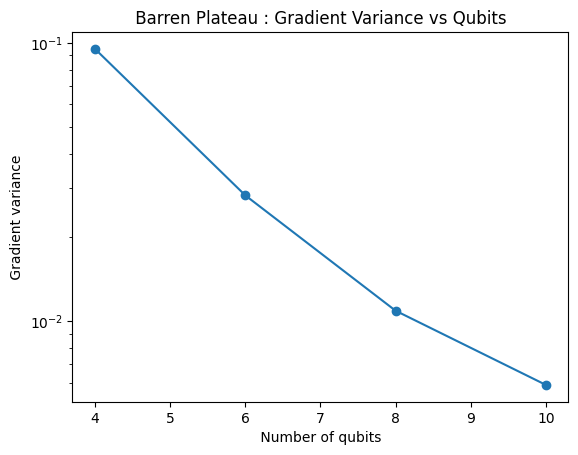

In [17]:
qubit_counts = [4 , 6 , 8 , 10]
variances = []
for n in qubit_counts :
    var = measure_gradient_variance(n , n_layers = n) # depth = width
    variances.append(var)
    print (f" n ={ n } qubits : Var [ grad ] = {var:.2e} " )

plt.semilogy( qubit_counts , variances , 'o-')
plt.xlabel(' Number of qubits ')
plt.ylabel(' Gradient variance ')
plt.title(' Barren Plateau : Gradient Variance vs Qubits ')
plt.show()